In [ ]:
# Heart Disease Prediction Project
# Author: Nermin Hodzic
# Description:
# This project uses a publicly available dataset to build and compare multiple classification models for predicting the presence of heart disease.
# The goal is to demonstrate the ability to preprocess data, visualize key patterns, and select the best performing algorithm.

# Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score




In [2]:
# Load dataset
df = pd.read_csv('heart.csv')  # Make sure this file is in the same directory

In [3]:
# Basic info
print(df.head())
print(df.info())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

In [4]:
# Check for missing values
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


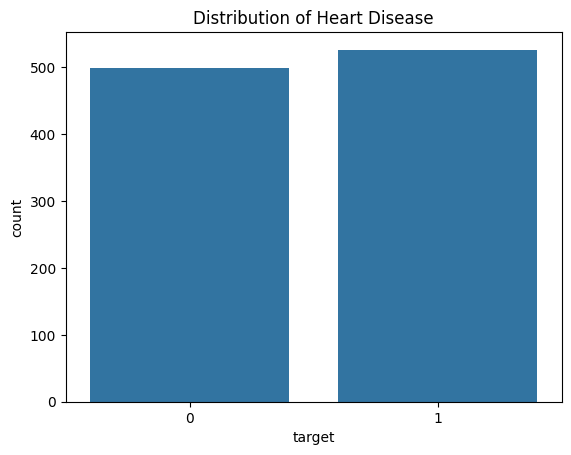

In [5]:
# Target variable distribution
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease')
plt.show()

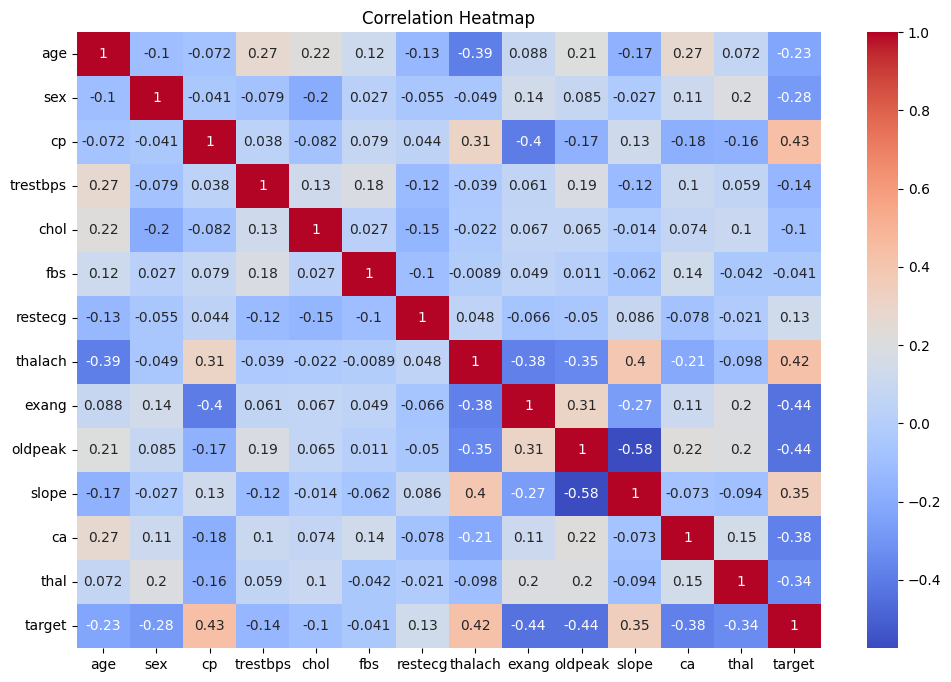

In [6]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

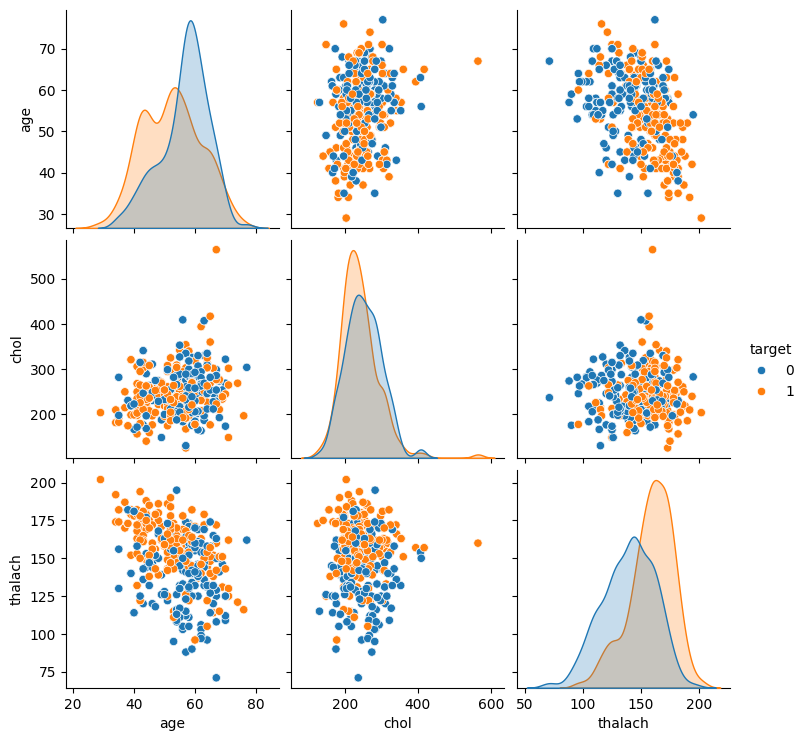

In [7]:
# Pairplot of selected features
sns.pairplot(df[['age', 'chol', 'thalach', 'target']], hue='target')
plt.show()

In [8]:
# Features and Target
X = df.drop('target', axis=1)
y = df['target']

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)  # Train the Logistic Regression model
log_pred = log_model.predict(X_test)  # Predict on the test set

In [12]:
# Evaluate Logistic Regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7951219512195122
[[73 29]
 [13 90]]
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [13]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)  # Train the Decision Tree model
tree_pred = tree_model.predict(X_test)  # Predict on the test set

In [14]:
# Evaluate Decision Tree
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print(confusion_matrix(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 0.9853658536585366
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [15]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
forest_model = RandomForestClassifier()
forest_model.fit(X_train, y_train)  # Train the Random Forest model
forest_pred = forest_model.predict(X_test)  # Predict on the test set


In [16]:
# Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, forest_pred))
print(confusion_matrix(y_test, forest_pred))
print(classification_report(y_test, forest_pred))

Random Forest Accuracy: 0.9853658536585366
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [17]:
# Support Vector Machine (SVM)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

In [18]:
# Define hyperparameter grid for SVM
param_grid = {
    "C": [0.1, 1, 10],                   # Regularization parameter
    "kernel": ["linear", "rbf", "poly"]  # Kernel types to test
}

In [19]:
# GridSearchCV for hyperparameter tuning
grid_svm = GridSearchCV(SVC(), param_grid, cv=5)  # 5-fold cross-validation
grid_svm.fit(X_train, y_train)  # Fit model with best parameters


GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10],
                         'kernel': ['linear', 'rbf', 'poly']})

In [20]:
# Get best model from grid search
best_svm = grid_svm.best_estimator_
svm_pred = best_svm.predict(X_test)  # Predict with optimized model

In [21]:
# Evaluate optimized SVM
print("Optimized SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

Optimized SVM Accuracy: 0.975609756097561
[[100   2]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       102
           1       0.98      0.97      0.98       103

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



/var/folders/6g/xwdswvms0mzcqctt2l12n33w0000gn/T/ipykernel_3231/750055610.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


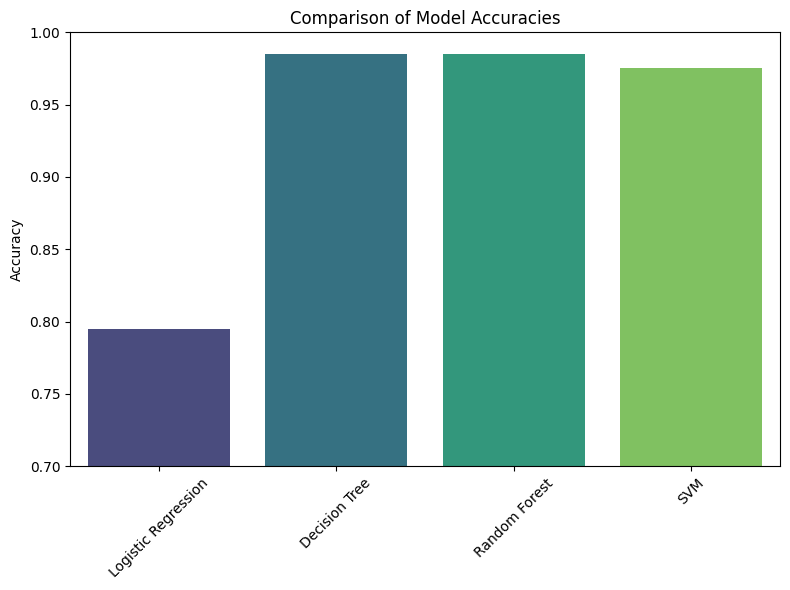

In [22]:
# Calculate individual accuracies
logistic_acc = accuracy_score(y_test, log_model.predict(X_test))
tree_acc = accuracy_score(y_test, tree_model.predict(X_test))
forest_acc = accuracy_score(y_test, forest_model.predict(X_test))
svm_acc = accuracy_score(y_test, best_svm.predict(X_test))

# Store the results
accuracies = [logistic_acc, tree_acc, forest_acc, svm_acc]
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']

# Plotting accuracy comparison
plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
# Final Remarks:
# After training and evaluating multiple classification models,
# Random Forest gave the best overall performance with the highest accuracy.
# The Support Vector Machine (SVM) model was further fine-tuned using GridSearchCV,
# which slightly improved its accuracy but still underperformed compared to Random Forest.
# This project demonstrates the importance of model selection and hyperparameter tuning
# when building classification models in healthcare datasets.